# Link Prediction in Actor Co-occurrence Network

## 1. Problem Statement

The goal of this competition is to predict missing links in an actor co-occurrence network. The network represents actors as nodes, and edges indicate co-occurrence on the same Wikipedia page, which serves as a proxy for joint participation in movies, personal relations, or fame levels.

Edges have been randomly deleted from the original graph, and non-edges (label 0) have been added to the training set. We must reconstruct the initial network using both graph-theoretical features and node features derived from Wikipedia textual information.

### Available Files:
- **train.txt**: 10,000 labeled node pairs (source, target, label: 1 for edge, 0 for non-edge).
- **test.txt**: 3,498 unlabeled pairs to predict.
- **node_information.csv**: 932-dimensional feature vectors for each node (first column is node ID).
- **random_submission.csv**: Sample submission format.

### Evaluation:
- Submissions scored on Kaggle, with final grading on private test set.
- Metric: Likely ROC AUC or similar for binary classification.

The task involves feature engineering from graph structure and node features, model selection, and tuning to achieve high accuracy.

## 2. Imports and Data Loading

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load data
node_info = pd.read_csv('node_information.csv', header=None)
train_data = pd.read_csv('train.txt', sep=' ', header=None, names=['source', 'target', 'label'])
test_data = pd.read_csv('test.txt', sep=' ', header=None, names=['source', 'target'])
submission_sample = pd.read_csv('random_predictions.csv')

print("Node info shape:", node_info.shape)
print("Train data shape:", train_data.shape)
print("Test data shape:", test_data.shape)
print("Submission sample shape:", submission_sample.shape)

Node info shape: (3597, 933)
Train data shape: (10496, 3)
Test data shape: (3498, 2)
Submission sample shape: (3498, 2)


## 3. Initial Data Inspection

In [3]:
# Inspect data
print("Train data head:")
print(train_data.head())
print("\nTest data head:")
print(test_data.head())
print("\nNode info head:")
print(node_info.head())

# Check for duplicates
print("\nDuplicates in train:", train_data.duplicated().sum())
print("Duplicates in test:", test_data.duplicated().sum())

# Node ID ranges
print("\nTrain node IDs range:", train_data[['source', 'target']].min().min(), "-", train_data[['source', 'target']].max().max())
print("Test node IDs range:", test_data[['source', 'target']].min().min(), "-", test_data[['source', 'target']].max().max())
print("Node info IDs range:", node_info[0].min(), "-", node_info[0].max())

# Check if all IDs in train/test are in node_info
train_ids = set(train_data['source']).union(set(train_data['target']))
test_ids = set(test_data['source']).union(set(test_data['target']))
node_ids = set(node_info[0])
print("\nAll train IDs in node_info:", train_ids.issubset(node_ids))
print("All test IDs in node_info:", test_ids.issubset(node_ids))

Train data head:
   source  target  label
0     939    3809      1
1    2442    5784      1
2     179    3809      1
3     857    2280      1
4    1358    5722      1

Test data head:
   source  target
0    3425    4524
1    1620    2617
2    4832    6317
3    4984    7298
4     385    5481

Node info head:
   0    1    2    3    4    5    6    7    8    9    ...  923  924  925  926  \
0    0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
1    4  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
2    5  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
3    6  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
4    7  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   

   927  928  929  930  931  932  
0  0.0  0.0  0.0  0.0  0.0  0.0  
1  0.0  0.0  0.0  0.0  0.0  0.0  
2  0.0  0.0  0.0  0.0  0.0  0.0  
3  0.0  0.0  0.0  0.0  0.0  0.0  
4  0.0  0.0  0.0  0.0  0.0  0.0  

[5 ro

## 4. Node Feature Analysis

Feature matrix shape: (3597, 932)
Feature sparsity: 0.9942160909007387
Feature means: 0.005783909099261306
Feature stds: 0.05360245223044622
PCA explained variance: [0.00712299 0.00594417]


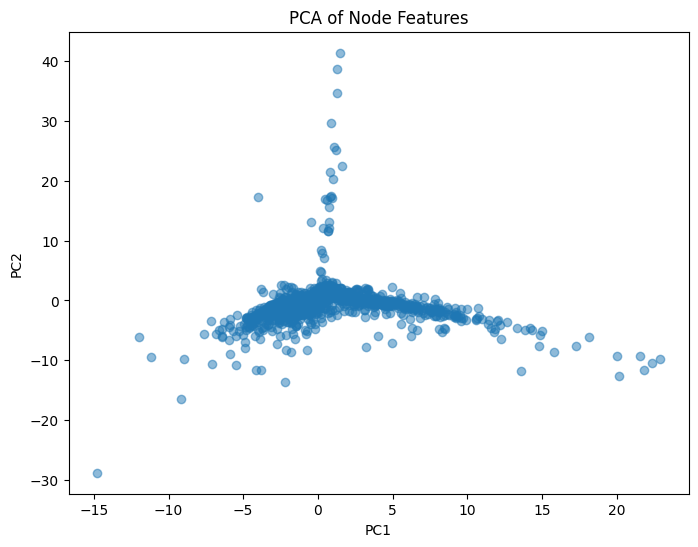

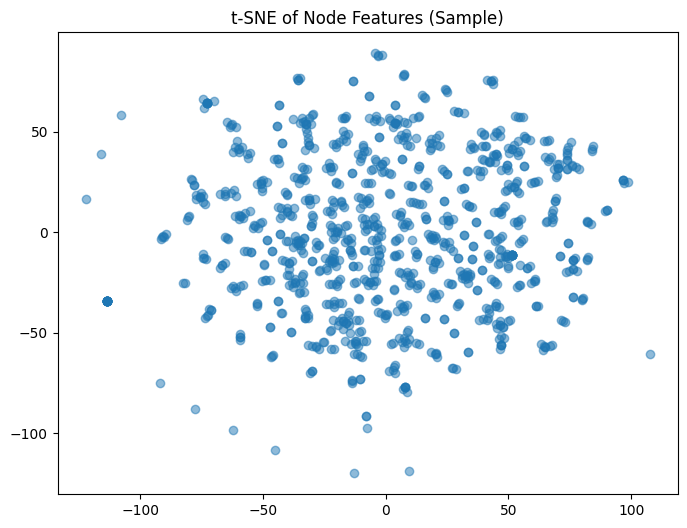

In [4]:
# Node features: 932 dimensions
features = node_info.iloc[:, 1:]
print("Feature matrix shape:", features.shape)

# Sparsity
sparsity = (features == 0).sum().sum() / (features.shape[0] * features.shape[1])
print("Feature sparsity:", sparsity)

# Feature statistics
print("Feature means:", features.mean().mean())
print("Feature stds:", features.std().mean())

# PCA for dimensionality reduction
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(features_scaled)
print("PCA explained variance:", pca.explained_variance_ratio_)

# Plot PCA
plt.figure(figsize=(8,6))
plt.scatter(pca_result[:,0], pca_result[:,1], alpha=0.5)
plt.title('PCA of Node Features')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

# t-SNE (sample for speed)
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
tsne_result = tsne.fit_transform(features_scaled[:1000])  # Sample
plt.figure(figsize=(8,6))
plt.scatter(tsne_result[:,0], tsne_result[:,1], alpha=0.5)
plt.title('t-SNE of Node Features (Sample)')
plt.show()

## 5. Training Set Label Distribution

Label distribution:
label
1    5248
0    5248
Name: count, dtype: int64
Positive fraction: 0.5


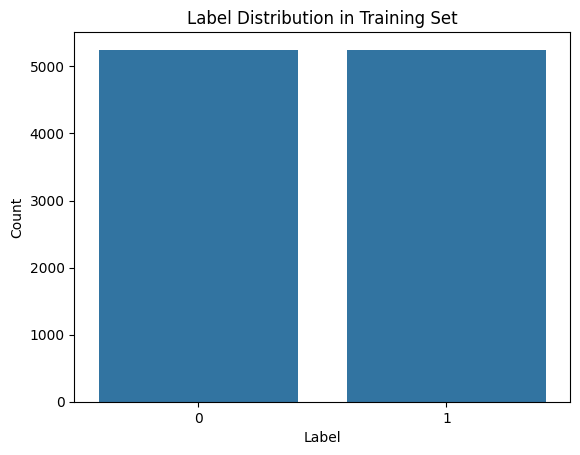

In [6]:
# Label distribution
label_counts = train_data['label'].value_counts()
print("Label distribution:")
print(label_counts)
print("Positive fraction:", label_counts[1] / len(train_data))

# Plot
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title('Label Distribution in Training Set')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

# Class imbalance: Note that there are more 0s, so stratification needed for CV.

## 6. Graph Construction from train.txt

In [7]:
# Build graph from positive edges
G = nx.Graph()
positive_edges = train_data[train_data['label'] == 1][['source', 'target']].values
G.add_edges_from(positive_edges)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

# Degrees
degrees = dict(G.degree())
degree_values = list(degrees.values())
print("Average degree:", np.mean(degree_values))
print("Max degree:", max(degree_values))

# Connected components
components = list(nx.connected_components(G))
print("Number of connected components:", len(components))
print("Largest component size:", len(max(components, key=len)))

# Clustering coefficient
clustering = nx.average_clustering(G)
print("Average clustering coefficient:", clustering)

# Centrality (degree centrality for simplicity)
degree_centrality = nx.degree_centrality(G)
print("Top 5 nodes by degree centrality:", sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5])

Number of nodes: 3597
Number of edges: 5248
Average degree: 2.917987211565193
Max degree: 361
Number of connected components: 1
Largest component size: 3597
Average clustering coefficient: 0.01956005840630179
Top 5 nodes by degree centrality: [(np.int64(3809), 0.10038932146829811), (np.int64(6416), 0.013348164627363737), (np.int64(7272), 0.010289210233592881), (np.int64(7082), 0.010289210233592881), (np.int64(7571), 0.010011123470522803)]


## 7. Graph-Theoretic Feature Extraction

In [8]:
# Example: Compute features for a small sample of pairs
sample_pairs = train_data.sample(100, random_state=42)[['source', 'target']].values

features_list = []
for u, v in sample_pairs:
    if u in G and v in G:
        # Common neighbors
        cn = len(list(nx.common_neighbors(G, u, v)))
        # Jaccard
        jaccard = list(nx.jaccard_coefficient(G, [(u, v)]))[0][2]
        # Adamic-Adar
        aa = list(nx.adamic_adar_index(G, [(u, v)]))[0][2]
        # Preferential attachment
        pa = list(nx.preferential_attachment(G, [(u, v)]))[0][2]
        # Shortest path (if connected)
        try:
            sp = nx.shortest_path_length(G, u, v)
        except:
            sp = -1
        features_list.append([cn, jaccard, aa, pa, sp])
    else:
        features_list.append([0, 0, 0, 0, -1])

# Convert to DataFrame
graph_features = pd.DataFrame(features_list, columns=['common_neighbors', 'jaccard', 'adamic_adar', 'pref_attachment', 'shortest_path'])
print(graph_features.head())

   common_neighbors  jaccard  adamic_adar  pref_attachment  shortest_path
0                 0      0.0          0.0               36              1
1                 0      0.0          0.0             1083              1
2                 0      0.0          0.0                4              5
3                 0      0.0          0.0                4              1
4                 0      0.0          0.0              308              1


## 8. Subgraph Sampling and Interactive Visualization

In [9]:
# Sample subgraph: top 10 degree nodes and their neighbors
top_nodes = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:10]
top_node_ids = [n for n, d in top_nodes]
subgraph_nodes = set(top_node_ids)
for n in top_node_ids:
    subgraph_nodes.update(G.neighbors(n))
subgraph = G.subgraph(list(subgraph_nodes))

print("Subgraph nodes:", len(subgraph))
print("Subgraph edges:", subgraph.number_of_edges())

# Interactive plot with Plotly
pos = nx.spring_layout(subgraph)
edge_x = []
edge_y = []
for edge in subgraph.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

node_x = [pos[n][0] for n in subgraph.nodes()]
node_y = [pos[n][1] for n in subgraph.nodes()]
node_degrees = [degrees.get(n, 0) for n in subgraph.nodes()]

fig = go.Figure()
fig.add_trace(go.Scatter(x=edge_x, y=edge_y, mode='lines', line=dict(width=0.5, color='#888'), hoverinfo='none', name='edges'))
fig.add_trace(go.Scatter(x=node_x, y=node_y, mode='markers', marker=dict(size=[d*2 for d in node_degrees], color=node_degrees, colorscale='Viridis', showscale=True), text=[f'Node {n}, Degree {d}' for n, d in zip(subgraph.nodes(), node_degrees)], hoverinfo='text', name='nodes'))
fig.update_layout(title='Interactive Subgraph Visualization', showlegend=False)
fig.show()

Subgraph nodes: 633
Subgraph edges: 856


In [10]:
# Full Graph Visualization
print("Computing layout for full graph...")
pos_full = nx.spring_layout(G, seed=42)  # Use spring layout for full graph

edge_x_full = []
edge_y_full = []
for edge in G.edges():
    x0, y0 = pos_full[edge[0]]
    x1, y1 = pos_full[edge[1]]
    edge_x_full.extend([x0, x1, None])
    edge_y_full.extend([y0, y1, None])

node_x_full = [pos_full[n][0] for n in G.nodes()]
node_y_full = [pos_full[n][1] for n in G.nodes()]
node_degrees_full = [degrees.get(n, 0) for n in G.nodes()]

fig_full = go.Figure()
fig_full.add_trace(go.Scatter(x=edge_x_full, y=edge_y_full, mode='lines', line=dict(width=0.5, color='#888'), hoverinfo='none', name='edges'))
fig_full.add_trace(go.Scatter(x=node_x_full, y=node_y_full, mode='markers', 
                             marker=dict(size=[max(5, d*0.5) for d in node_degrees_full], 
                                         color=node_degrees_full, colorscale='Viridis', showscale=True,
                                         colorbar=dict(title="Degree")),
                             text=[f'Node {n}, Degree {d}' for n, d in zip(G.nodes(), node_degrees_full)], 
                             hoverinfo='text', name='nodes'))

# Add indicators as annotations
indicators_text = f"""
Nodes: {G.number_of_nodes()}
Edges: {G.number_of_edges()}
Average Degree: {np.mean(degree_values):.2f}
Max Degree: {max(degree_values)}
Connected Components: {len(components)}
Largest Component: {len(max(components, key=len))}
Average Clustering: {clustering:.4f}
"""

fig_full.add_annotation(text=indicators_text, x=0.02, y=0.98, xref="paper", yref="paper", 
                        showarrow=False, font=dict(size=12), align="left", 
                        bgcolor="rgba(255,255,255,0.8)", bordercolor="black", borderwidth=1)

fig_full.update_layout(title='Interactive Full Graph Visualization with Indicators', 
                       showlegend=False, 
                       xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                       yaxis=dict(showgrid=False, zeroline=False, showticklabels=False))

# Save to HTML
fig_full.write_html('full_graph.html')
print("Full graph saved to full_graph.html")

# Show in notebook
fig_full.show()

Computing layout for full graph...
Full graph saved to full_graph.html


In [11]:
# 3D Full Graph Visualization
print("Computing 3D layout for full graph...")
pos_3d = nx.spring_layout(G, dim=3, seed=42)

edge_x_3d = []
edge_y_3d = []
edge_z_3d = []
for edge in G.edges():
    x0, y0, z0 = pos_3d[edge[0]]
    x1, y1, z1 = pos_3d[edge[1]]
    edge_x_3d.extend([x0, x1, None])
    edge_y_3d.extend([y0, y1, None])
    edge_z_3d.extend([z0, z1, None])

node_x_3d = [pos_3d[n][0] for n in G.nodes()]
node_y_3d = [pos_3d[n][1] for n in G.nodes()]
node_z_3d = [pos_3d[n][2] for n in G.nodes()]
node_degrees_3d = [degrees.get(n, 0) for n in G.nodes()]

fig_3d = go.Figure()
fig_3d.add_trace(go.Scatter3d(x=edge_x_3d, y=edge_y_3d, z=edge_z_3d, mode='lines', 
                             line=dict(width=1, color='#888'), hoverinfo='none', name='edges'))
fig_3d.add_trace(go.Scatter3d(x=node_x_3d, y=node_y_3d, z=node_z_3d, mode='markers',
                             marker=dict(size=[max(5, d*0.5) for d in node_degrees_3d],
                                         color=node_degrees_3d, colorscale='Viridis', showscale=True,
                                         colorbar=dict(title="Degree")),
                             text=[f'Node {n}, Degree {d}' for n, d in zip(G.nodes(), node_degrees_3d)],
                             hoverinfo='text', name='nodes'))

# Add indicators as annotation
fig_3d.add_annotation(text=indicators_text, x=0.02, y=0.98, xref="paper", yref="paper",
                      showarrow=False, font=dict(size=12), align="left",
                      bgcolor="rgba(255,255,255,0.8)", bordercolor="black", borderwidth=1)

fig_3d.update_layout(title='Interactive 3D Full Graph Visualization with Indicators',
                     showlegend=False,
                     scene=dict(xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                                yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                                zaxis=dict(showgrid=False, zeroline=False, showticklabels=False)))

# Save to HTML
fig_3d.write_html('full_graph_3d.html')
print("3D full graph saved to full_graph_3d.html")

# Show in notebook
fig_3d.show()

Computing 3D layout for full graph...
3D full graph saved to full_graph_3d.html


## 9. Feature Engineering Ideas (text + graph)

In [ ]:
# Ideas:
# - Concatenate node features for pairs: [feat_u, feat_v]
# - Difference: |feat_u - feat_v|
# - Hadamard: feat_u * feat_v
# - Combine with graph features
# - Use node embeddings from node2vec or spectral clustering
# - Feature selection: Correlation, mutual info, or model-based (e.g., RF feature importance)

# Example: Simple concatenation for sample
sample_features = []
for u, v in sample_pairs[:10]:
    feat_u = features.loc[node_info[0] == u].values.flatten()[1:]
    feat_v = features.loc[node_info[0] == v].values.flatten()[1:]
    concat = np.concatenate([feat_u, feat_v])
    diff = np.abs(feat_u - feat_v)
    hadamard = feat_u * feat_v
    sample_features.append(np.concatenate([concat, diff, hadamard]))

print("Combined feature shape for one pair:", len(sample_features[0]))

## 10. Modeling Strategy and Next Steps

In [ ]:
# Next steps:
# - Implement full feature extraction for all pairs
# - Train models: Logistic Regression, Random Forest, XGBoost
# - Use stratified CV due to imbalance
# - Tune hyperparameters with GridSearch or RandomSearch
# - Evaluate with ROC AUC
# - Consider GNNs like GraphSAGE for node embeddings
# - Ensure reproducibility: Fix random seeds, save models

# Baseline: Logistic Regression on graph features
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Assuming we have full features (placeholder)
# X = full_feature_matrix
# y = train_data['label']
# model = LogisticRegression()
# scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
# print("CV AUC:", scores.mean())